In [48]:
import numpy as np
from typing import List, Optional, Any

class Topic:
    def __init__(
        self,
        document_embeddings_hd: np.ndarray,
        document_embeddings_ld: Optional[np.ndarray] = None,
        centroid_hd: Optional[np.ndarray] = None,
        documents: Optional[List[str]] = None,
        topic_name: Optional[str] = None,
        topic_desc: Optional[str] = None
    ):
        assert isinstance(document_embeddings_hd, np.ndarray), "document_embeddings_hd must be a numpy array"
        if centroid_hd is not None:
            assert isinstance(centroid_hd, np.ndarray), "centroid_hd must be a numpy array"
        if documents is not None:
            assert isinstance(documents, list), "documents must be a list of strings"
        self.document_embeddings_hd = document_embeddings_hd
        self.centroid_hd = centroid_hd
        self.documents = documents or []
        self.topic_name = topic_name
        self.topic_desc = topic_desc
        if document_embeddings_ld is not None:
            assert isinstance(document_embeddings_ld, np.ndarray), "document_embeddings_ld must be a numpy array"
            self.document_embeddings_ld = document_embeddings_ld
        else:
            self.document_embeddings_ld = None

In [49]:
import pickle

with open("truncated_docs_topic_objs.pkl", "rb") as f:
    topic_objs = pickle.load(f)

# Check the number of topics loaded
print(f"Loaded {len(topic_objs)} topics.")

# Check the first topic's name and number of documents
print(topic_objs[0].topic_name, len(topic_objs[0].documents))

Loaded 20 topics.
Sports Team Evaluations 1851


In [50]:
for topic in topic_objs:
    print(f"Topic: {topic.topic_name}, description: {topic.topic_desc}, num documents: {len(topic.documents)}")

Topic: Sports Team Evaluations, description: Sports analysis covering NHL goaltenders' performances and team standings, MLB predictions, and hockey-related discussions like player ratings and fighting in the league., num documents: 1851
Topic: Computer Hardware for Sale, description: Comparison of SCSI and IDE interfaces for drives, including performance, compatibility, and cost considerations for PCs and Macs. Discussions on expansion options and drive transfer rates., num documents: 1911
Topic: Armenian genocide of Muslims, description: Armenian involvement in the alleged genocide of 2.5 million Muslim people, disputed historical accounts, and its impact on political discourse., num documents: 754
Topic: Telephone Line Voltage Monitoring, description: Telephone Line Technical Issues, num documents: 45
Topic: Becoming a NASA astronaut, description: Space Exploration Overview, num documents: 813
Topic: Government Handling of Firearms JADX, description: Controversy surrounding governmen

In [51]:
from sklearn.metrics.pairwise import cosine_similarity
import warnings
from typing import List, Optional, Any


class ADC:
    """
    Average Document Coherence (ADC) metric for topic models.
    """

    def __init__(
        self,
        n_docs: int = -1,  # -1 means all docs in the cluster
        n_intruder_docs: int = 1,
    ):
        assert isinstance(n_docs, int), "n_docs must be an integer"
        assert isinstance(n_intruder_docs, int), "n_intruder_docs must be an integer"
        self.n_docs = n_docs
        self.n_intruder_docs = n_intruder_docs

    def score_one_intr_per_cluster(
        self,
        topic_list: List[Topic],
        random_state: Optional[Any] = None,
    ) -> np.ndarray:
        rng = np.random.default_rng(random_state)
        emb_clusters: List[np.ndarray] = []
        for t in topic_list:
            emb = getattr(t, "document_embeddings_hd", None)
            assert isinstance(emb, np.ndarray), "Topic objects must have document_embeddings_hd field populated as numpy array."
            arr = np.atleast_2d(np.asarray(emb))
            if self.n_docs is not None and self.n_docs > 0 and arr.size > 0:
                n_available = arr.shape[0]
                if n_available > self.n_docs:
                    centroid = getattr(t, "centroid_hd", None)
                    if centroid is None:
                        centroid = arr.mean(axis=0)
                    else:
                        centroid = np.asarray(centroid).reshape(-1)
                    sims = cosine_similarity(centroid.reshape(1, -1), arr).flatten()
                    top_idx = np.argsort(sims)[-self.n_docs:][::-1]
                    arr = arr[top_idx]
            emb_clusters.append(arr)

        scores: List[float] = []
        for i, cluster_emb in enumerate(emb_clusters):
            if cluster_emb.size == 0:
                scores.append(np.nan)
                continue
            other = [np.atleast_2d(c) for j, c in enumerate(emb_clusters) if j != i and c.size > 0]
            if len(other) == 0:
                scores.append(np.nan)
                continue
            other_embs = np.vstack(other)
            intr_idx = int(rng.integers(0, other_embs.shape[0]))
            intr_embedding = other_embs[intr_idx]
            sim = cosine_similarity(intr_embedding.reshape(1, -1), cluster_emb)  # (1, n_docs)
            sim = (sim + 1) / 2  # Scale to [0, 1]
            scores.append(float(np.mean(sim)))
        return np.array(scores)

    def score_per_cluster(self, topic_list: List[Topic]) -> dict:
        score_lis: List[np.ndarray] = []
        for _ in range(self.n_intruder_docs):
            score_per_cluster = self.score_one_intr_per_cluster(
                topic_list
            )
            score_lis.append(score_per_cluster)
        res = np.vstack(score_lis).T
        mean_scores = np.mean(res, axis=1)
        ntopics = len(topic_list)
        results: dict = {}
        for k in range(ntopics):
            preview = ""
            t = topic_list[k]
            if getattr(t, "documents", None):
                preview = " - " + str(t.documents[0])[:40].replace("\n", " ").strip()
            label = f"cluster_{k}{preview}"
            results[label] = float(np.round(mean_scores[k], 5))
        return results

    def score(self, topics: List[Topic]) -> float:
        scores = list(self.score_per_cluster(topics).values())
        if all(np.isnan(scores)):
            warnings.warn("ADC: All clusters returned NaN (no valid intruder comparisons possible).")
            return np.nan
        return float(np.nanmean(scores))

In [52]:
import numpy as np
import re
from typing import List, Optional, Any
from sklearn.metrics.pairwise import cosine_similarity

class ADS:
    """
    Average Description Similarity (ADS) metric for topic models.
    The average cosine similarity of the embedding of each document d
    to the embedding of the description of the topic assigned to d.
    """

    def __init__(self, n_docs: int = -1, embedder: Optional[Any] = None):
        """
        Args:
            n_docs (int): Number of documents per topic to use (-1 means all).
            embedder: An object with a .get_embeddings(list_of_texts) method returning a dict with 'embeddings' key.
        """
        self.n_docs = n_docs
        self.embedder = embedder

    def get_info(self) -> dict:
        """
        Get information about the metric.
        """
        info = {
            "metric_name": "Average Description Similarity (ADS)",
            "n_docs": self.n_docs,
            "metric_range": "0 to 1, higher is better",
            "description": "The average cosine similarity (scaled to [0,1]) between the embedding of each document and the embedding of its topic description.",
        }
        return info

    def score(self, topics: List[Any]) -> float:
        """
        Args:
            topics: List of Topic-like objects, each with:
                - topic_description (str)
                - document_embeddings_hd (np.ndarray)
                - centroid_hd (optional, np.ndarray)
        Returns:
            float: The average ADS score across all topics.
        """
        assert isinstance(topics, (list, tuple)), "topics must be a list or tuple of Topic objects"
        assert self.embedder is not None, "embedder must be provided"

        # Clean the descriptions
        descriptions = [self.clean_description(getattr(t, "topic_description", "")) for t in topics]

        # Embed the topic descriptions
        # topic_desc_embeddings = self.embedder.get_embeddings(descriptions)["embeddings"]
        topic_desc_embeddings = self.embedder.encode(descriptions, convert_to_numpy=True)

        # Embed the documents in each topic
        emb_clusters: List[np.ndarray] = []
        for t in topics:
            emb = getattr(t, "document_embeddings_hd", None)
            assert emb is not None, "Each topic must have 'document_embeddings_hd'"
            arr = np.atleast_2d(np.asarray(emb))
            # If n_docs > 0, select the most representative documents (top-k by similarity to centroid)
            if self.n_docs is not None and self.n_docs > 0 and arr.size > 0:
                n_available = arr.shape[0]
                n_select = min(self.n_docs, n_available)
                centroid = getattr(t, "centroid_hd", None)
                if centroid is None:
                    centroid = arr.mean(axis=0)
                else:
                    centroid = np.asarray(centroid).reshape(-1)
                sims = cosine_similarity(centroid.reshape(1, -1), arr).flatten()
                top_idx = np.argsort(sims)[-n_select:][::-1]
                arr = arr[top_idx]
            emb_clusters.append(arr)

        similarity_scores: List[float] = []
        for i in range(len(emb_clusters)):
            desc = topic_desc_embeddings[i].reshape(1, -1)
            docs = emb_clusters[i]
            if docs.size == 0:
                similarity_scores.append(np.nan)
                continue
            sims = cosine_similarity(desc, docs)  # Shape: (1, n_docs)
            sims_01 = (sims + 1) / 2  # Now in [0, 1]
            similarity_scores.append(np.nanmean(sims_01))  # Average similarity for the topic

        if len(similarity_scores) == 0 or np.all(np.isnan(similarity_scores)):
            return np.nan
        return round(np.nanmean(similarity_scores), 4)

    @staticmethod
    def clean_description(desc: str) -> str:
        if not desc:
            return ""
        desc = desc.strip().strip('\'"')
        desc = re.sub(r'(\*\*|\*|`)+', '', desc)
        desc = re.sub(r'^#{1,6}\s*', '', desc, flags=re.MULTILINE)
        desc = re.sub(r'^\s*[\-\*\+]\s+', '', desc, flags=re.MULTILINE)
        desc = re.sub(r'^\s*\d+\.\s+', '', desc, flags=re.MULTILINE)
        desc = re.sub(r'\s+', ' ', desc)
        return desc.strip()

In [53]:
import numpy as np
import re
from typing import List, Optional, Any
from sklearn.metrics.pairwise import cosine_similarity

class ADS_Intruder:
    """
    Intruder-based Average Description Similarity (ADS) metric for topic models.
    Compares each cluster's documents with all other clusters' descriptions (intruders).
    """

    def __init__(self, n_docs: int = -1, embedder: Optional[Any] = None):
        """
        Args:
            n_docs (int): Number of documents per topic to use (-1 means all).
            embedder: An object with .encode() method for embedding texts.
        """
        self.n_docs = n_docs
        self.embedder = embedder

    def get_info(self) -> dict:
        """
        Get information about the metric.
        """
        info = {
            "metric_name": "Intruder-based Average Description Similarity (ADS-Intruder)",
            "n_docs": self.n_docs,
            "metric_range": "-1 to 1, lower is better",
            "description": "Average cosine similarity between cluster documents and intruder topic descriptions. Lower scores indicate better topic separation.",
        }
        return info

    def score(self, topics: List[Any]) -> float:
        """
        Args:
            topics: List of Topic-like objects, each with:
                - topic_desc (str): topic description
                - document_embeddings_hd (np.ndarray): document embeddings
                - centroid_hd (optional, np.ndarray): cluster centroid
        Returns:
            float: The average intruder ADS score across all topics.
        """
        assert isinstance(topics, (list, tuple)), "topics must be a list or tuple of Topic objects"
        assert self.embedder is not None, "embedder must be provided"

        # Clean the descriptions and embed them
        descriptions = [self.clean_description(getattr(t, "topic_desc", "")) for t in topics]
        topic_desc_embeddings = self.embedder.encode(descriptions, convert_to_numpy=True)

        # Prepare document embeddings for each cluster
        emb_clusters: List[np.ndarray] = []
        for t in topics:
            emb = getattr(t, "document_embeddings_hd", None)
            assert emb is not None, "Each topic must have 'document_embeddings_hd'"
            arr = np.atleast_2d(np.asarray(emb))
            
            # If n_docs > 0, select the most representative documents
            if self.n_docs is not None and self.n_docs > 0 and arr.size > 0:
                n_available = arr.shape[0]
                n_select = min(self.n_docs, n_available)
                centroid = getattr(t, "centroid_hd", None)
                if centroid is None:
                    centroid = arr.mean(axis=0)
                else:
                    centroid = np.asarray(centroid).reshape(-1)
                sims = cosine_similarity(centroid.reshape(1, -1), arr).flatten()
                top_idx = np.argsort(sims)[-n_select:][::-1]
                arr = arr[top_idx]
            emb_clusters.append(arr)

        # Calculate intruder similarities for each cluster
        cluster_scores: List[float] = []
        
        for i, cluster_docs in enumerate(emb_clusters):
            if cluster_docs.size == 0:
                cluster_scores.append(np.nan)
                continue
            
            intruder_similarities: List[float] = []
            
            # Compare with all other clusters' descriptions (intruders)
            for j, intruder_desc_emb in enumerate(topic_desc_embeddings):
                if j == i:  # Skip own description
                    continue
                
                # Calculate similarity between intruder description and cluster documents
                intruder_desc = intruder_desc_emb.reshape(1, -1)
                sims = cosine_similarity(intruder_desc, cluster_docs)  # Shape: (1, n_docs)
                avg_sim = np.mean(sims)  # Average similarity for this intruder
                intruder_similarities.append(avg_sim)
            
            # Average across all intruder descriptions for this cluster
            if intruder_similarities:
                cluster_scores.append(np.mean(intruder_similarities))
            else:
                cluster_scores.append(np.nan)

        # Final average across all clusters
        if len(cluster_scores) == 0 or np.all(np.isnan(cluster_scores)):
            return np.nan
        
        return round(np.nanmean(cluster_scores), 4)

    @staticmethod
    def clean_description(desc: str) -> str:
        if not desc:
            return ""
        desc = desc.strip().strip('\'"')
        desc = re.sub(r'(\*\*|\*|`)+', '', desc)
        desc = re.sub(r'^#{1,6}\s*', '', desc, flags=re.MULTILINE)
        desc = re.sub(r'^\s*[\-\*\+]\s+', '', desc, flags=re.MULTILINE)
        desc = re.sub(r'^\s*\d+\.\s+', '', desc, flags=re.MULTILINE)
        desc = re.sub(r'\s+', ' ', desc)
        return desc.strip()

In [54]:
adc = ADC(n_docs=-1, n_intruder_docs=1000)
result = adc.score(topic_objs)
print("ADC score on dummy data:", result)

KeyboardInterrupt: 

In [45]:
# Pre-calculate embeddings
from sentence_transformers import SentenceTransformer
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

adc = ADS(n_docs=-1, embedder=embedding_model)
result = adc.score(topic_objs)
print("ADC score on dummy data:", result)

ADC score on dummy data: 0.541


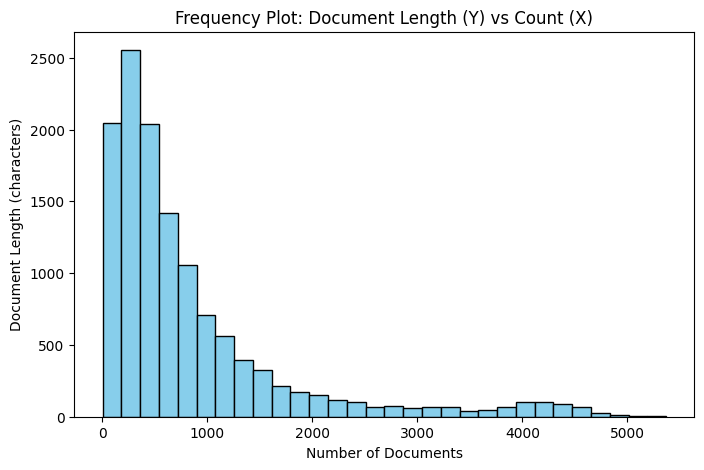

In [46]:
import matplotlib.pyplot as plt

doc_lengths = []
for topic in topic_objs:
    for doc in topic.documents:
        doc_lengths.append(len(doc))

# Plot horizontal histogram: y-axis = length, x-axis = frequency
plt.figure(figsize=(8, 5))
plt.hist(doc_lengths, bins=30, color='skyblue', edgecolor='black', orientation='vertical')
plt.ylabel('Document Length (characters)')
plt.xlabel('Number of Documents')
plt.title('Frequency Plot: Document Length (Y) vs Count (X)')
plt.show()

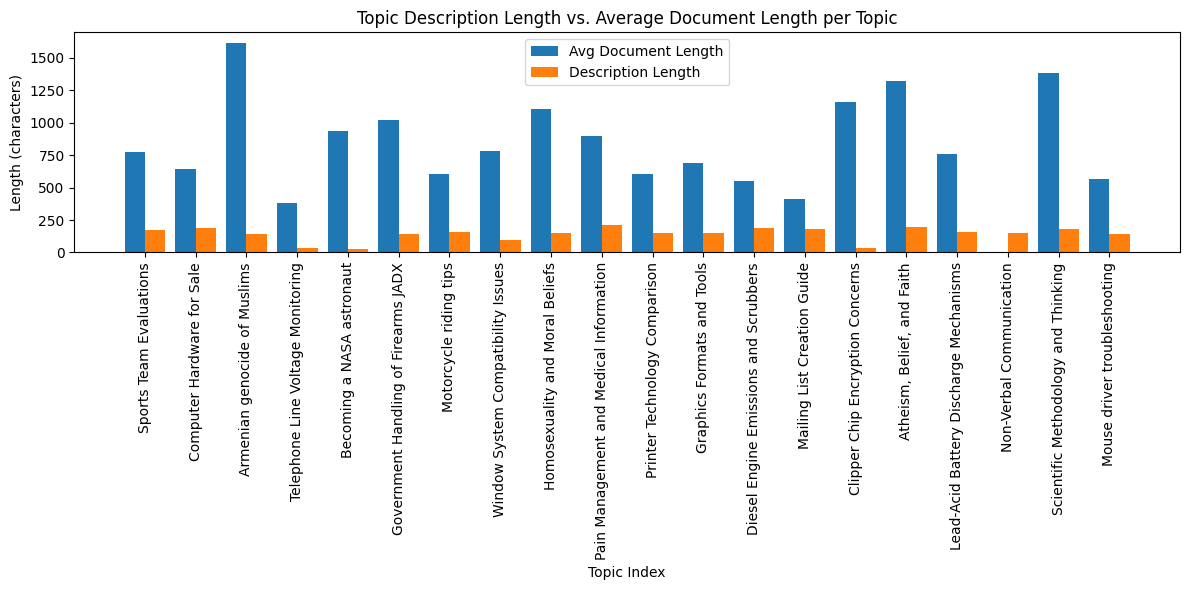

In [47]:
import matplotlib.pyplot as plt
import numpy as np

avg_doc_lengths = []
desc_lengths = []
topic_labels = []

for topic in topic_objs:
    avg_doc_lengths.append(np.mean([len(doc) for doc in topic.documents]))
    desc_lengths.append(len(topic.topic_desc) if topic.topic_desc else 0)
    topic_labels.append(topic.topic_name if topic.topic_name else "")

x = np.arange(len(topic_objs))

plt.figure(figsize=(12, 6))
plt.bar(x - 0.2, avg_doc_lengths, width=0.4, label='Avg Document Length')
plt.bar(x + 0.2, desc_lengths, width=0.4, label='Description Length')
plt.xlabel('Topic Index')
plt.ylabel('Length (characters)')
plt.title('Topic Description Length vs. Average Document Length per Topic')
plt.legend()
plt.xticks(x, topic_labels, rotation=90)
plt.tight_layout()
plt.show()